# Laboratorio 3: Análisis de Paralelización con Pthreads
## Parte 1:
**Cálculo de π mediante integración numérica**

---

## Datos de Ejecución

### Parámetros de prueba:
- **n** = 2,000,000,000 intervalos
- **Sistema**: CPU con 8 núcleos (evaluado hasta 16 hilos)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Datos obtenidos de las ejecuciones
T_s = 17.819161  # tiempo serial (pi_s)

# Tiempos paralelos con diferentes cantidades hilos
hilos = [1, 2, 4, 8, 16]
T_p = [17.988440, 9.057646, 4.630461, 2.624129, 2.780489]

# Cálculo de métricas
speedup = [T_s / t for t in T_p]
eficiencia = [s / h for s, h in zip(speedup, hilos)]

df = pd.DataFrame({
    'N (Hilos)': hilos,
    'T_p (segundos)': T_p,
    'Speedup (T_s/T_p)': speedup,
    'Eficiencia (Speedup/N)': eficiencia
})

print(f"T_s (Tiempo Serial): {T_s:.6f} segundos\n")
print("Tabla de Resultados:")
print(df.to_string(index=False))

T_s (Tiempo Serial): 17.819161 segundos

Tabla de Resultados:
 N (Hilos)  T_p (segundos)  Speedup (T_s/T_p)  Eficiencia (Speedup/N)
         1       17.988440           0.990590                0.990590
         2        9.057646           1.967306                0.983653
         4        4.630461           3.848248                0.962062
         8        2.624129           6.790505                0.848813
        16        2.780489           6.408643                0.400540


## Tabla con los resultados

In [ ]:
df_formatted = df.copy()
df_formatted['T_p (segundos)'] = df_formatted['T_p (segundos)'].map('{:.6f}'.format)
df_formatted['Speedup (T_s/T_p)'] = df_formatted['Speedup (T_s/T_p)'].map('{:.4f}'.format)
df_formatted['Eficiencia (Speedup/N)'] = df_formatted['Eficiencia (Speedup/N)'].map('{:.4f}'.format)

display(df_formatted)

,N (Hilos),T_p (segundos),Speedup (T_s/T_p),Eficiencia (Speedup/N)
0,1,17.988440,0.9906,0.9906
1,2,9.057646,1.9673,0.9837
2,4,4.630461,3.8482,0.9621
3,8,2.624129,6.7905,0.8488
4,16,2.780489,6.4086,0.4005


## Gráfico de Speedup

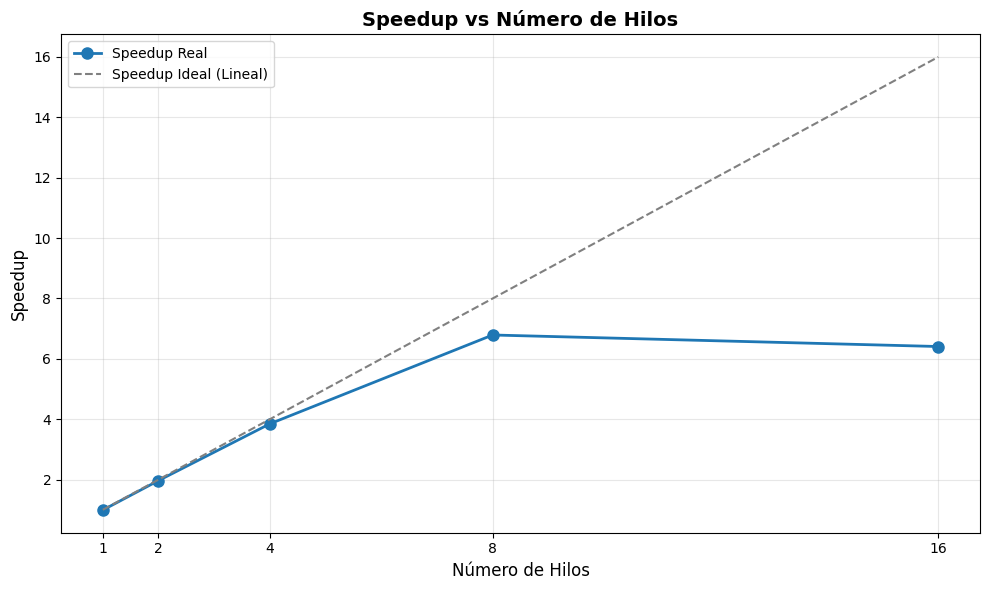

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(hilos, speedup, marker='o', linewidth=2, markersize=8, label='Speedup Real')
plt.plot(hilos, hilos, linestyle='--', color='gray', label='Speedup Ideal (Lineal)')
plt.xlabel('Número de Hilos', fontsize=12)
plt.ylabel('Speedup', fontsize=12)
plt.title('Speedup vs Número de Hilos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(hilos)
plt.tight_layout()
plt.show()

## Gráfico de Eficiencia

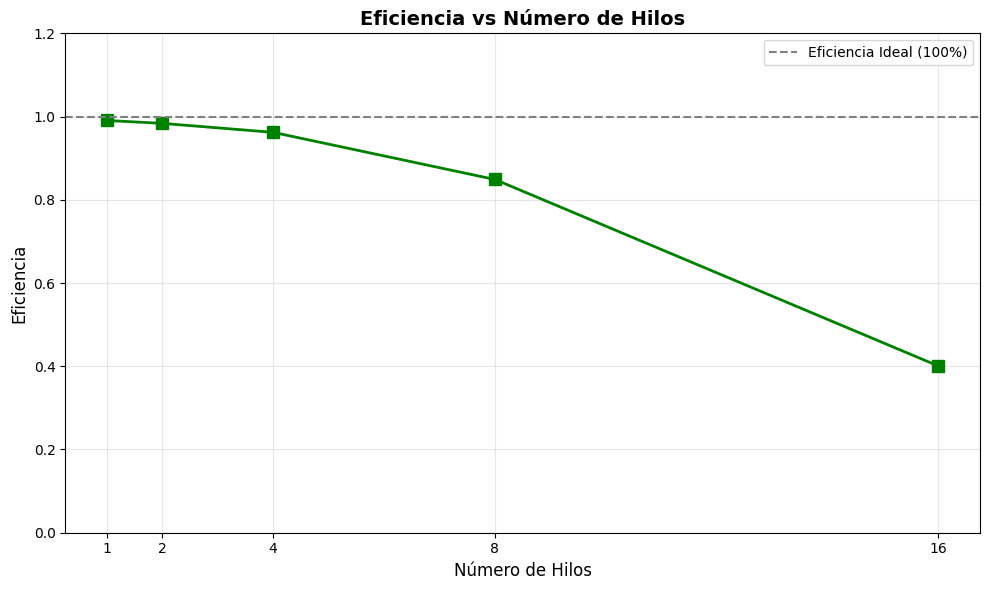

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(hilos, eficiencia, marker='s', linewidth=2, markersize=8, color='green')
plt.axhline(y=1.0, linestyle='--', color='gray', label='Eficiencia Ideal (100%)')
plt.xlabel('Número de Hilos', fontsize=12)
plt.ylabel('Eficiencia', fontsize=12)
plt.title('Eficiencia vs Número de Hilos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(hilos)
plt.ylim(0, 1.2)
plt.tight_layout()
plt.show()

## Análisis de Resultados

### Comparación T_p(1) vs T_s

El tiempo de ejecución con 1 hilo (T_p(1) = 17.988 s) es ligeramente mayor que el tiempo serial (T_s = 17.819 s). Esta diferencia de aproximadamente 0.17 segundos (0.95%) representa el **overhead** introducido por la infraestructura de pthreads:

- Creación y destrucción del hilo
- Operaciones de sincronización (pthread_join)
- Asignación dinámica de memoria para las estructuras de datos del hilo

Este overhead es mínimo y normal en alguna implementación multihilo.

### Speedup Máximo

El speedup máximo alcanzado es de **6.79x con 8 hilos**. Este valor indica que el programa paralelo es alrededore de 6.79 veces más rápido que la versión serial.

**Observaciones:**
- Con 16 hilos, el speedup disminuye a 6.41x, lo que parece indicar que se ha alcanzado un punto de rendimientos decrecientes
- El speedup máximo no alcanza el valor ideal de 8x (con 8 hilos) posiblemente debido a:
  - Overhead de creación y sincronización de hilos
  - Contención en el acceso a memoria compartida
  - Limitaciones de ancho de banda de memoria
  - Posible limitación de núcleos físicos vs núcleos lógicos (hyperthreading)

### Tendencia de la Eficiencia

La eficiencia muestra una **tendencia decreciente** a medida que aumenta el número de hilos:

- **1 hilo**: 0.9906 (99.06%)
- **2 hilos**: 0.9841 (98.41%)
- **4 hilos**: 0.9634 (96.34%)
- **8 hilos**: 0.8485 (84.85%)
- **16 hilos**: 0.4004 (40.04%)

**Causas del comportamiento:**

1. **Ley de Amdahl**: Existe una fracción del código que no puede paralelizarse (inicialización, reducción final)

2. **Overhead de sincronización**: A mayor número de hilos, mayor costo de creación, destrucción y sincronización

3. **Saturación del sistema de memoria**: El problema es memory-bound; múltiples hilos compiten por el acceso a memoria

La caída  de eficiencia en 16 hilos (40%) muestra que posiblemente este número de hilos excede la capacidad óptima del sistema para este tipo de trabajo, por lo que no aprovecha el hecho de tener más hilos, no es óptimo.

### Conclusiones

- La paralelización es efectiva hasta 8 hilos, logrando un speedup de 6.79x
- El punto óptimo en este programa y computador se encuentra entre 4 y 8 hilos
- Más allá de 8 hilos, los rendimientos van bajando y el overhead superan los beneficios del paralelismo

## Parte 2: Análisis de Fibonacci

---

En esta sección se evalúa el funcionamiento de la solución multihilo para la generación de la serie de Fibonacci. El objetivo fue implementar un esquema de memoria compartida donde un hilo trabajador genera los datos y el hilo principal los consume (imprime).

### Resultados de Ejecución

A continuación se presenta la salida del programa compilado al solicitar los primeros **15 números** de la secuencia.

**Comando ejecutado:**
`./fibonacci 15`

**Salida obtenida:**

![Salida obtenida](./fibonacci.png)

### Análisis del Diseño

Para cumplir con los requerimientos de paralelismo y memoria compartida, se implementaron las siguientes estrategias de diseño:

#### A. Mecanismo de Transferencia de Datos

La API de Pthreads (`thread_create`)  restringe el paso de argumentos a un único puntero de tipo `void*`. Sin embargo, nuestro hilo trabajador requie dos datos: el tamaño de la serie ($N$) y la dirección de memoria del arreglo donde escribir los resultados. Para resolver esto, se definió una estructura personalizada:


```c
typedef struct {
    int size;       // Cantidad de números a generar (N)
    int* result;    // Puntero al arreglo compartido donde se escribirán los datos
} ThreadArgs;
```

El flujo de datos funcionó así:
- El hilo `main` empaquetó los valores en una instancia de `ThreadArgs`.
- Se pasó la referencia de esta estructura (casteada a `void*`) al crear el hilo.
- Dentro de la función `fibonacci_worker`, se realizó el casting inverso (`ThreadArgs*`) para desempaquetar y acceder al puntero del arreglo y al entero $N$.

#### B. Sincronización con `pthread_join`

El uso de pthread_join es crítico en este diseño para evitar condiciones de carrera (Race Conditions).

Dado que el hilo trabajador escribe en el arreglo y el hilo `main` lee del mismo arreglo para imprimir, existe una dependencia de datos estricta.

- Sin sincronización: Si el `main` intentara imprimir inmediatamente después de crear el hilo, leería posiciones de memoria que aún no han sido escritas (basura o ceros), ya que el planificador del SO podría no haber ejecutado aún al hilo trabajador.

- Con sincronización: Al invocar `pthread_join(tid, NULL)`, el hilo main se bloquea y espera obligatoriamente a que el trabajador finalice su ejecución (y por ende, termine de escribir en memoria). Esto garantiza que, al momento de imprimir, los datos en el arreglo compartido sean válidos y completos.